In [1]:
import pysr
pysr.install()

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


c:\Users\SVSTORE\AppData\Local\Programs\Python\Python313\Lib\site-packages\pysr\deprecated.py:10: FutureWarning: The `install` function has been removed. PySR now uses the `juliacall` package to install its dependencies automatically at import time. 
  warnings.warn(


In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, PredefinedSplit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from tqdm import tqdm

print("""ETERNAL GLORY TO THE CIVILIZED AND HEROIC VIETNAMESE NATION!
LONG LIVE THE GLORIOUS COMMUNIST PARTY OF VIETNAM!
LONG LIVE THE SOCIALIST REPUBLIC OF VIETNAM!
THE GREAT PRESIDENT HO CHI MINH LIVES FOREVER IN OUR CAUSE!""")

c:\Users\SVSTORE\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ETERNAL GLORY TO THE CIVILIZED AND HEROIC VIETNAMESE NATION!
LONG LIVE THE GLORIOUS COMMUNIST PARTY OF VIETNAM!
LONG LIVE THE SOCIALIST REPUBLIC OF VIETNAM!
THE GREAT PRESIDENT HO CHI MINH LIVES FOREVER IN OUR CAUSE!


In [17]:
df = pd.read_csv('hh.csv', sep=';', decimal=',')
df.columns = df.columns.str.strip()


target = 'PAS_ustd'  # Biến phụ thuộc (Y)
features = ['ALD_ustd'] # Biến độc lập (X)

X = df[features]
y = df[target]

print("Số lượng dòng bị thiếu dữ liệu (NaN):", df.isna().sum().sum())

print(f"✅ CHÚC ĐỒNG CHÍ KHỎE! Biến mục tiêu hiện tại là: {target}")

Số lượng dòng bị thiếu dữ liệu (NaN): 0
✅ CHÚC ĐỒNG CHÍ KHỎE! Biến mục tiêu hiện tại là: PAS_ustd


In [18]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

SEED = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED)

param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [200, 400],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_lambda': [1.0, 5.0, 10.0]
}

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
xgb_base = xgb.XGBRegressor(random_state=SEED, objective='reg:squarederror', n_jobs=-1)

# Định nghĩa nhiều thang đo cùng lúc (đã thay neg_MSE thành neg_MAE)
scoring_metrics = {
    'R2': 'r2',
    'neg_RMSE': 'neg_root_mean_squared_error',
    'neg_MAE': 'neg_mean_absolute_error' 
}

print("Đang quét lưới tham số và tính R², RMSE, MAE cho 5-Fold CV... (Sẽ mất vài phút)")
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=cv,
    scoring=scoring_metrics,
    refit='R2', # Yêu cầu GridSearch chọn mô hình tốt nhất dựa trên R²
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

# =====================================================================
# TRÍCH XUẤT CHỈ SỐ CỦA 5-FOLD CV VÀ TẬP TEST
# =====================================================================
# 1. Trích xuất chỉ số CV của BỘ THAM SỐ TỐI ƯU NHẤT
best_idx = grid_search.best_index_
cv_r2 = grid_search.cv_results_['mean_test_R2'][best_idx]
cv_rmse = -grid_search.cv_results_['mean_test_neg_RMSE'][best_idx] 
cv_mae = -grid_search.cv_results_['mean_test_neg_MAE'][best_idx]   # Đổi sang tính CV MAE

# 2. Tính toán trên tập Train
preds_train = best_model.predict(X_train)
train_r2 = r2_score(y_train, preds_train)

# 3. Tính toán trên tập Test
preds_test = best_model.predict(X_test)
test_r2 = r2_score(y_test, preds_test)
test_rmse = np.sqrt(mean_squared_error(y_test, preds_test))
test_mae = mean_absolute_error(y_test, preds_test) # Đổi sang tính Test MAE

# IN KẾT QUẢ CUỐI CÙNG
print("\n" + "=" * 70)
print("🏆 KẾT QUẢ HUẤN LUYỆN XGBOOST (CÓ CHỈ SỐ 5-FOLD CHUẨN)")
print("=" * 70)
print("Bộ tham số tối ưu:")
for k, v in grid_search.best_params_.items():
    print(f"   - {k}: {v}")

print("\n📊 HIỆU SUẤT TRÊN TẬP HUẤN LUYỆN (TRAIN 80%):")
print(f"   - R²:   {train_r2:.4f}")

print("\n🔄 HIỆU SUẤT TRUNG BÌNH QUA 5-FOLD CROSS VALIDATION:")
print(f"   - R²:   {cv_r2:.4f}")
print(f"   - RMSE: {cv_rmse:.4f}")
print(f"   - MAE:  {cv_mae:.4f}") # In ra MAE

print("\n🎯 HIỆU SUẤT TRÊN TẬP KIỂM TRA (TEST 20% - DÙNG ĐỂ BÁO CÁO):")
print(f"   - R²:   {test_r2:.4f}")
print(f"   - RMSE: {test_rmse:.4f}")
print(f"   - MAE:  {test_mae:.4f}") # In ra MAE
print("=" * 70)

# =====================================================================
# THÊM MỚI: LƯU CÁC CHỈ SỐ VÀO BIẾN best_metrics ĐỂ DÙNG CHO PySR
# =====================================================================
best_metrics = {
    'CV Valid R2 (Trung bình 5 Fold)': cv_r2,
    'Train R2': train_r2,
    'Test R2': test_r2,
    'CV RMSE': cv_rmse,
    'Test RMSE': test_rmse,
    'CV MAE': cv_mae,    # Đã thêm MAE vào dict lưu trữ
    'Test MAE': test_mae # Đã thêm MAE vào dict lưu trữ
}
print("\n✅ Đã lưu các chỉ số vào biến 'best_metrics' thành công. Bạn có thể chạy ô code PySR tiếp theo!")

Đang quét lưới tham số và tính R², RMSE, MAE cho 5-Fold CV... (Sẽ mất vài phút)
Fitting 5 folds for each of 486 candidates, totalling 2430 fits

🏆 KẾT QUẢ HUẤN LUYỆN XGBOOST (CÓ CHỈ SỐ 5-FOLD CHUẨN)
Bộ tham số tối ưu:
   - colsample_bytree: 0.7
   - learning_rate: 0.01
   - max_depth: 3
   - n_estimators: 400
   - reg_lambda: 10.0
   - subsample: 0.7

📊 HIỆU SUẤT TRÊN TẬP HUẤN LUYỆN (TRAIN 80%):
   - R²:   0.2280

🔄 HIỆU SUẤT TRUNG BÌNH QUA 5-FOLD CROSS VALIDATION:
   - R²:   0.1936
   - RMSE: 1.0336
   - MAE:  0.8205

🎯 HIỆU SUẤT TRÊN TẬP KIỂM TRA (TEST 20% - DÙNG ĐỂ BÁO CÁO):
   - R²:   0.1391
   - RMSE: 1.0830
   - MAE:  0.8484

✅ Đã lưu các chỉ số vào biến 'best_metrics' thành công. Bạn có thể chạy ô code PySR tiếp theo!


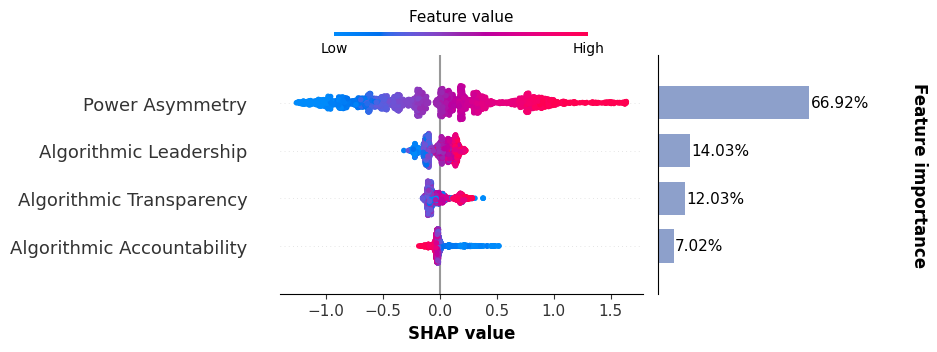

In [33]:
import shap
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

# Giả định biến target 
target_display = "Algorithmic Accountability"  # Thay thế bằng tên hiển thị mong muốn

# 1. Khởi tạo Explainer và trích xuất giá trị SHAP
explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X)
shap_matrix = shap_values.values

# 2. Quy chuẩn hệ thống nhãn dán khái niệm học thuật sang TÊN VIẾT DÀI
feature_mapping = {
    'ALD_ustd': 'Algorithmic Leadership',
    'AAC_ustd': 'Algorithmic Accountability',
    'TRU_ustd': 'Algorithmic Trust',
    'ATP_ustd': 'Algorithmic Transparency',
    'AVR_ustd': 'Algorithmic Aversion',
    'PAS_ustd': 'Power Asymmetry'
}

X_display = X.copy()
# Chuyển đổi toàn bộ tên cột sang tên viết dài dựa trên dictionary
X_display.columns = [feature_mapping.get(col, col) for col in X_display.columns]

# 3. Tính toán độ quan trọng tương đối (phần trăm)
mean_abs_shap = np.abs(shap_matrix).mean(axis=0)
total_shap = mean_abs_shap.sum()
percentages = (mean_abs_shap / total_shap) * 100

sorted_idx = np.argsort(mean_abs_shap)
sorted_percentages = percentages[sorted_idx]

# 4. Cấu hình không gian đồ thị
fig = plt.figure(figsize=(12, 7.5))
gs = fig.add_gridspec(1, 2, width_ratios=[1.5, 1], wspace=0.05)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharey=ax1)

# 5. Kết xuất biểu đồ beeswarm (Bên trái)
plt.sca(ax1)
# Ẩn thanh màu mặc định dọc của SHAP
shap.summary_plot(shap_matrix, X_display, show=False, color_bar=False)
ax1.set_xlabel("SHAP value", fontweight='bold', fontsize=12)

# ====================================================================
# BỔ SUNG COLORBAR "Feature value" NẰM NGANG Ở TRÊN CÙNG AX1
# ====================================================================
cax = ax1.inset_axes([0.15, 1.08, 0.7, 0.015])
cmap = shap.plots.colors.red_blue 
norm = mcolors.Normalize(vmin=0, vmax=1)
cb = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm),
                  cax=cax, orientation="horizontal")

cax.set_title("Feature value", fontsize=11, pad=8)
cb.set_ticks([0, 1])
cb.set_ticklabels(["Low", "High"])
cb.outline.set_visible(False)    
cb.ax.tick_params(length=0)      
# ====================================================================

# 6. Kết xuất biểu đồ thanh ngang phần trăm (Bên phải)
num_features = len(X_display.columns) 
y_pos = np.arange(num_features)
ax2.barh(y_pos, sorted_percentages, color='#8DA0CB', height=0.7)

for i, v in enumerate(sorted_percentages):
    ax2.text(v + 0.5, i, f"{v:.2f}%", va='center', fontsize=11, color='black')

# 7. Tinh chỉnh thẩm mỹ trục bar chart
# SỬA Ở ĐÂY: Tăng khoảng trống padding bên phải từ +12 lên +40
ax2.set_xlim(0, max(sorted_percentages) + 40)
ax2.yaxis.set_label_position("right")
ax2.set_ylabel("Feature importance", rotation=270, labelpad=20, fontweight='bold', fontsize=12)

plt.setp(ax2.get_yticklabels(), visible=False)
ax2.tick_params(axis='y', length=0)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.xaxis.set_visible(False)



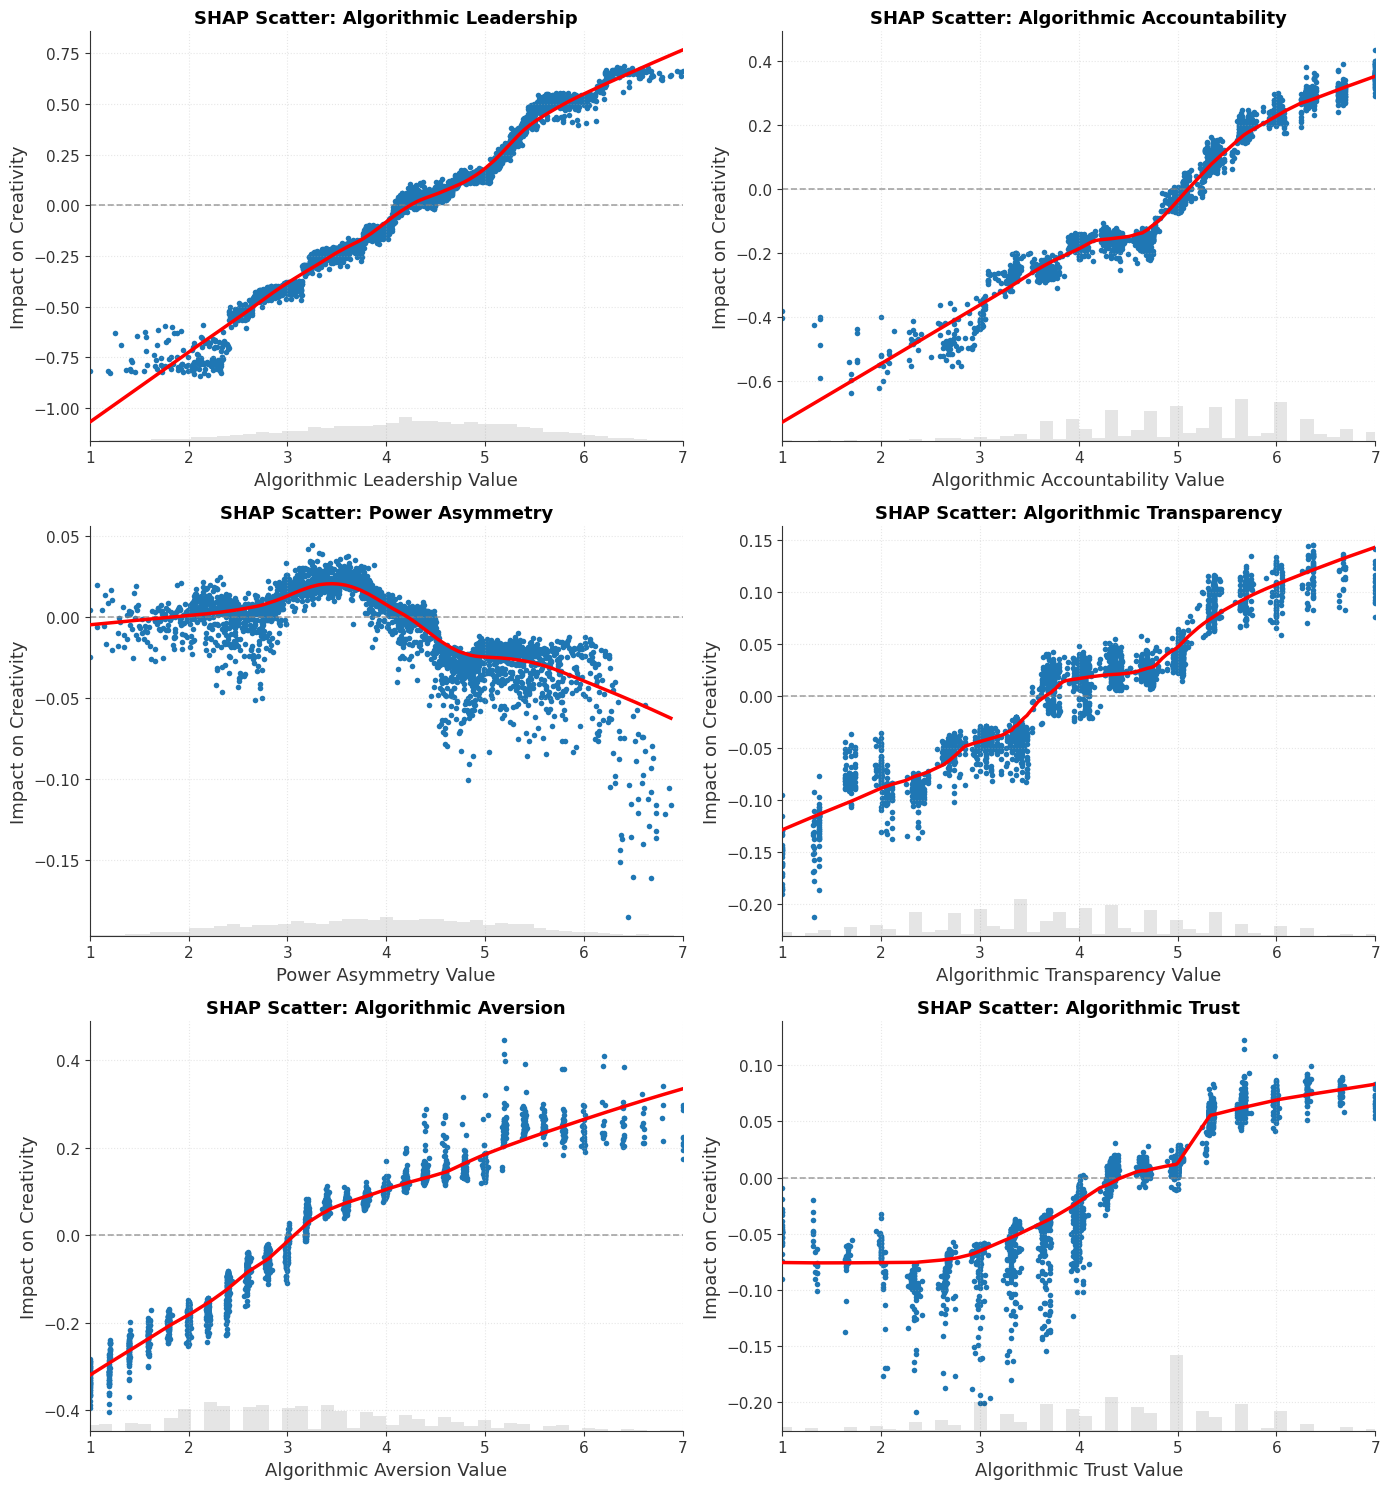

In [8]:
import matplotlib.pyplot as plt
import shap
import statsmodels.api as sm
import numpy as np
import math

# ==========================================
# 0. KHAI BÁO MAPPING VÀ TARGET Ở ĐẦY
# ==========================================
# Đưa feature_mapping lên trên cùng để dùng cho cả target
feature_mapping = {
    'ALD_ustd': 'Algorithmic Leadership',
    'AAC_ustd': 'Algorithmic Accountability',
    'TRU_ustd': 'Algorithmic Trust',
    'ATP_ustd': 'Algorithmic Transparency',
    'AVR_ustd': 'Algorithmic Aversion',
    'PAS_ustd': 'Power Asymmetry'
}

# Giả sử target của bạn đang là AAC_ustd
target = 'Creativity'  # Thay thế bằng tên biến mục tiêu thực tế của bạn

# SỬA Ở ĐÂY: Tra cứu tên đẹp từ dictionary. Nếu không có trong dict thì mới cắt đuôi '_ustd'
target_display = feature_mapping.get(target, target.replace('_ustd', ''))

# ==========================================
# 1. CALCULATE SHAP FOR ALL ORIGINAL DATA (X)
# ==========================================
explainer = shap.TreeExplainer(best_model)
shap_values_all = explainer(X)

# ==========================================
# 2. LIST OF FEATURES TO PLOT
# ==========================================
features_to_plot = ['ALD_ustd', 'AAC_ustd', 'PAS_ustd', 'ATP_ustd', 'AVR_ustd', 'TRU_ustd']  # Thay thế bằng danh sách các biến bạn muốn vẽ

# Grid settings: 2 columns, rows calculated based on number of features
cols = 2
rows = math.ceil(len(features_to_plot) / cols)

# Initialize dynamic figure frame (height increases with number of rows)
fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = np.array(axes).flatten() 

# ==========================================
# 3. LOOP TO PLOT EACH SUBPLOT
# ==========================================
for i, feature in enumerate(features_to_plot):
    ax = axes[i]

    # Get display name from dictionary for X-axis
    display_name = feature_mapping.get(feature, feature)

    # Plot SHAP Scatter
    shap.plots.scatter(
        shap_values_all[:, feature],
        show=False,
        ax=ax,
        color='#1f77b4'
    )

    # Calculate and plot red LOWESS line
    x_vals = shap_values_all[:, feature].data
    y_vals = shap_values_all[:, feature].values

    # Skip NaN values if any, to avoid LOWESS errors
    valid_idx = ~np.isnan(x_vals) & ~np.isnan(y_vals)
    if valid_idx.sum() > 0:
        lowess = sm.nonparametric.lowess(y_vals[valid_idx], x_vals[valid_idx], frac=0.3)
        ax.plot(lowess[:, 0], lowess[:, 1], color='red', linewidth=2.5, zorder=5)

    # Customize labels for each subplot (English format)
    ax.set_title(f"SHAP Scatter: {display_name}", fontsize=13, fontweight='bold')
    
    # TRỤC Y BÂY GIỜ SẼ HIỂN THỊ TÊN ĐẦY ĐỦ (vd: Impact on Algorithmic Accountability)
    ax.set_ylabel(f"Impact on {target_display}")
    ax.set_xlabel(f"{display_name} Value")

    # Giới hạn trục Ox từ 1 đến 7
    ax.set_xlim(1, 7)

    ax.axhline(0, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)
    ax.grid(alpha=0.3, linestyle=':')

# Remove empty subplots if the number of features is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [37]:
from pysr import PySRRegressor
import numpy as np
from sklearn.metrics import r2_score
import warnings
import sympy  # Dùng để dịch công thức toán

# Tắt các cảnh báo lặt vặt làm rối màn hình
warnings.filterwarnings('ignore')

print("\n" + "="*50)
print("🧠 BẮT ĐẦU TÌM CÔNG THỨC VỚI PySR TRỰC TIẾP TỪ DỮ LIỆU GỐC")
print("="*50)

# 1. Chuyển X_train và y_train (Dữ liệu thực tế) sang NumPy thuần túy cho PySR
X_train_np = np.array(X_train, dtype=np.float32)
y_train_np = np.array(y_train, dtype=np.float32) # Dùng y_train thay vì dự đoán của XGBoost

# 2. Khai báo PySR (GIỮ NGUYÊN 100% SETTING BAN ĐẦU CỦA BẠN)
pysr_model = PySRRegressor(
    niterations=1000,
    maxsize=50,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=[
        "abs", "inv", "cbrt", "square", "cube", "exp", "log1p",
        "sqrt_abs(x) = sqrt(abs(x))",              
        "log_abs(x) = log(abs(x) + 1f-8)"          
    ],
    extra_sympy_mappings={
        "sqrt_abs": lambda x: sympy.sqrt(sympy.Abs(x)),
        "log_abs": lambda x: sympy.log(sympy.Abs(x) + 1e-8)
    },
    complexity_of_operators={
        "+": 1, "-": 1, "*": 1, "/": 1,
        "abs": 1, "inv": 2, "square": 2,
        "sqrt_abs": 3, "cbrt": 3, "cube": 3,
        "exp": 4, "log_abs": 4, "log1p": 4
    },
    nested_constraints={
        "exp": {"exp": 0, "log_abs": 0, "log1p": 0, "cube": 0},
        "log_abs": {"exp": 0, "log_abs": 0, "log1p": 0},
        "log1p": {"exp": 0, "log_abs": 0, "log1p": 0},
        "cube": {"cube": 0, "exp": 0},
        "inv": {"inv": 0},
        "square": {"square": 0, "cube": 0, "sqrt_abs": 0}
    },
    model_selection="accuracy",
    parsimony=0.0,
    random_state=42,
    deterministic=True,
    parallelism="serial",
    verbosity=0
)

# 3. Huấn luyện trực tiếp trên dữ liệu gốc (y_train_np)
print("⏳ Đang tiến hóa hàng triệu phương trình... (Vui lòng đợi vài phút)")
pysr_model.fit(X_train_np, y_train_np, variable_names=features)

# 4. Xuất kết quả
best_eq = pysr_model.sympy()
print("\n" + "="*50)
print("🏆 PHƯƠNG TRÌNH TOÁN HỌC TỐI ƯU NHẤT")
print("="*50)
print(f"\n{target} ≈ {best_eq}\n")

# ==========================================
# 5. ĐÁNH GIÁ LẠI ĐIỂM SỐ TRÊN TẬP HUẤN LUYỆN
# ==========================================
# Dự đoán lại bằng công thức trên tập huấn luyện
y_train_formula = pysr_model.predict(X_train_np)

# Tính R^2 của công thức so với dữ liệu THỰC TẾ
r2_formula_real = r2_score(y_train_np, y_train_formula)

print("-" * 60)
print(f"R² của Công thức PySR (Học từ dữ liệu gốc) : {r2_formula_real:.4f}")
print("-" * 60)
print("=> KẾT LUẬN:")
if r2_formula_real > 0:
    print(f"Công thức minh bạch đã giải thích được ~{r2_formula_real*100:.2f}% sự biến thiên của {target}.")
    print("Do học trực tiếp từ dữ liệu, kết quả này phản ánh sát với thực tế hơn so với qua trung gian XGBoost.")

# SỬ DỤNG .to_string() ĐỂ IN FULL TEXT, KHÔNG BỊ CẮT XÉN CHỮ
print("\nDANH SÁCH CÁC PHƯƠNG TRÌNH TIẾN HÓA:")
print(pysr_model.equations_[['complexity', 'loss', 'score', 'equation']].to_string())


🧠 BẮT ĐẦU TÌM CÔNG THỨC VỚI PySR TRỰC TIẾP TỪ DỮ LIỆU GỐC
⏳ Đang tiến hóa hàng triệu phương trình... (Vui lòng đợi vài phút)

🏆 PHƯƠNG TRÌNH TOÁN HỌC TỐI ƯU NHẤT

CRT_ustd ≈ log(Abs(ALD_ustd**3 + AVR_ustd*Abs(Abs((ALD_ustd + 0.0910644)/(ATP_ustd - 0.81585354) - 1/(PAS_ustd + TRU_ustd - 4.353116)) + (AAC_ustd + 0.94002986)/((-1.2172703/AAC_ustd))) - (ALD_ustd + ALD_ustd*2.2801218/TRU_ustd)*(ALD_ustd + PAS_ustd - 4.721603)) + 1.0e-8)

------------------------------------------------------------
R² của Công thức PySR (Học từ dữ liệu gốc) : 0.4246
------------------------------------------------------------
=> KẾT LUẬN:
Công thức minh bạch đã giải thích được ~42.46% sự biến thiên của CRT_ustd.
Do học trực tiếp từ dữ liệu, kết quả này phản ánh sát với thực tế hơn so với qua trung gian XGBoost.

DANH SÁCH CÁC PHƯƠNG TRÌNH TIẾN HÓA:
    complexity      loss     score                                                                                                                               

In [2]:
import numpy as np
import pandas as pd
!pip install SALib
import matplotlib.pyplot as plt
from SALib.sample import saltelli
from SALib.analyze import sobol

print("\n" + "="*60)
print("BƯỚC 5 (NÂNG CAO): PHÂN TÍCH ĐỘ NHẠY SOBOL & SỰ HỘI TỤ")
print("="*60)

# 1. Khai báo bài toán
problem = {
    'num_vars': len(features),
    'names': features,
    'bounds': [[X_train[col].min(), X_train[col].max()] for col in features]
}

# 2. Khảo sát đa cỡ mẫu giống y hệt bài báo (N = 2^5, 2^7, 2^9, 2^11, 2^13)
N_values = [2**5, 2**7, 2**9, 2**11, 2**13]

# Lưu trữ kết quả để vẽ biểu đồ
results_S1 = {feature: [] for feature in features}
results_ST = {feature: [] for feature in features}
errors_S1 = {feature: [] for feature in features}
errors_ST = {feature: [] for feature in features}

print(f"Đang chạy khảo sát cho các cỡ mẫu N = {N_values}...\n")

for n in N_values:
    # Lấy mẫu
    param_values = saltelli.sample(problem, n)

    # Dự đoán bằng công thức PySR
    Y_pred = pysr_model.predict(param_values)

    # Phân tích
    Si = sobol.analyze(problem, Y_pred, print_to_console=False)

    # Lưu lại giá trị và độ lệch (confidence interval) cho từng biến
    for i, feature in enumerate(features):
        results_S1[feature].append(Si['S1'][i])
        results_ST[feature].append(Si['ST'][i])
        errors_S1[feature].append(Si['S1_conf'][i])
        errors_ST[feature].append(Si['ST_conf'][i])

# ==========================================
# 3. XUẤT BẢNG TỔNG HỢP
# Lấy kết quả của N lớn nhất (2^13) để làm chuẩn
# ==========================================
final_Si = sobol.analyze(problem, pysr_model.predict(saltelli.sample(problem, 2**13)), print_to_console=False)
table_4 = pd.DataFrame({
    'Input Variables': features,
    'First-order S1': final_Si['S1'],
    'Total S_T': final_Si['ST']
})
print("BẢNG TỔNG HỢP CHỈ SỐ SOBOL (Tại N = 2^13 - Tương đương Table 4):")
print("-" * 60)
print(table_4.to_string(index=False))
print("-" * 60)

# ==========================================
# 4. VẼ BIỂU ĐỒ KHOẢNG TIN CẬY
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors = ['red', 'blue', 'green', 'purple', 'orange']
markers = ['D', 'v', '^', '>', '<']

# Trục X: Vị trí của các biến (X0, X1, ...)
x_pos = np.arange(len(features))

# Plot (a): First-order sensitivity indices
for i, n in enumerate(N_values):
    s1_vals = [results_S1[feat][i] for feat in features]
    s1_errs = [errors_S1[feat][i] for feat in features]
    # Dịch chuyển vị trí X một chút để các điểm không đè lên nhau
    offset = (i - 2) * 0.15
    ax1.errorbar(x_pos + offset, s1_vals, yerr=s1_errs, fmt=markers[i], color=colors[i],
                 label=f'N = 2^{int(np.log2(n))}', capsize=3, alpha=0.7)

ax1.set_xticks(x_pos)
ax1.set_xticklabels(features, rotation=15)
ax1.set_ylabel('First-order sensitivity indices S1')
ax1.set_xlabel('Input parameters of the model')
ax1.set_title('(a) First-order')
ax1.legend()

# Plot (b): Total sensitivity indices
for i, n in enumerate(N_values):
    st_vals = [results_ST[feat][i] for feat in features]
    st_errs = [errors_ST[feat][i] for feat in features]
    offset = (i - 2) * 0.15
    ax2.errorbar(x_pos + offset, st_vals, yerr=st_errs, fmt=markers[i], color=colors[i],
                 label=f'N = 2^{int(np.log2(n))}', capsize=3, alpha=0.7)

ax2.set_xticks(x_pos)
ax2.set_xticklabels(features, rotation=15)
ax2.set_ylabel('Total sensitivity indices ST')
ax2.set_xlabel('Input parameters of the model')
ax2.set_title('(b) Total')
ax2.legend()

plt.tight_layout()
plt.show()


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



BƯỚC 5 (NÂNG CAO): PHÂN TÍCH ĐỘ NHẠY SOBOL & SỰ HỘI TỤ


NameError: name 'features' is not defined

In [1]:
import math
import itertools

def calculate_crt(avr, pas, ald, aac, atp, tru):
    # Tách phương trình thành 3 phần cho dễ đọc và tránh sai sót
    term1 = 1.5719965
    term2 = math.log(1 + avr) * (0.6081236 - 0.011222351 * pas)
    term3_part1 = (0.024149785 * (ald / aac) + 0.026868502)
    term3_part2 = (8.680249 * aac + atp + 0.22264202 * ald * tru)
    
    term3 = term3_part1 * term3_part2
    
    return term1 + term2 + term3

# Các giá trị có thể có của mỗi biến (số nguyên từ 1 đến 7)
# range(1, 8) sẽ tạo ra các số 1, 2, 3, 4, 5, 6, 7
values = range(1, 8)

# Khởi tạo giá trị max, min ban đầu
max_crt = float('-inf')
min_crt = float('inf')

# Biến để lưu vết bộ thông số tốt nhất
best_max_vars = None
best_min_vars = None

# Vòng lặp duyệt qua mọi trường hợp (7^6 = 117,649 trường hợp)
print("Đang tính toán...")
for avr, pas, ald, aac, atp, tru in itertools.product(values, repeat=6):
    crt = calculate_crt(avr, pas, ald, aac, atp, tru)
    
    # Cập nhật Max
    if crt > max_crt:
        max_crt = crt
        best_max_vars = (avr, pas, ald, aac, atp, tru)
        
    # Cập nhật Min
    if crt < min_crt:
        min_crt = crt
        best_min_vars = (avr, pas, ald, aac, atp, tru)

# In kết quả
print("="*40)
print(f"GIÁ TRỊ MAX CRT = {max_crt:.5f}")
print(f"Đạt được khi: AVR={best_max_vars[0]}, PAS={best_max_vars[1]}, ALD={best_max_vars[2]}, AAC={best_max_vars[3]}, ATP={best_max_vars[4]}, TRU={best_max_vars[5]}")
print("-" * 40)
print(f"GIÁ TRỊ MIN CRT = {min_crt:.5f}")
print(f"Đạt được khi: AVR={best_min_vars[0]}, PAS={best_min_vars[1]}, ALD={best_min_vars[2]}, AAC={best_min_vars[3]}, ATP={best_min_vars[4]}, TRU={best_min_vars[5]}")
print("="*40)

Đang tính toán...
GIÁ TRỊ MAX CRT = 8.02259
Đạt được khi: AVR=7, PAS=1, ALD=7, AAC=1, ATP=7, TRU=7
----------------------------------------
GIÁ TRỊ MIN CRT = 2.44429
Đạt được khi: AVR=1, PAS=7, ALD=1, AAC=1, ATP=1, TRU=1


In [39]:
import numpy as np
from scipy.optimize import differential_evolution

# Định nghĩa hàm tính Y_hat dựa trên công thức
def calculate_y_hat(x):
    # x là một mảng chứa 6 biến: [AVR, ATP, ALD, AAC, PAS, TRU]
    avr, atp, ald, aac, pas, tru = x
    
    # Sử dụng np.cbrt để tính căn bậc 3 an toàn cho cả số âm
    inner_cbrt_val = avr - (atp / ald)
    term1 = (np.cbrt(inner_cbrt_val) / ald) + ald
    
    term2 = (aac / 0.655) + avr
    
    inner_expr = (term1 * term2 * 2.323) - pas + atp - (0.559 * (avr / tru))
    
    return np.cbrt(inner_expr)

# Hàm mục tiêu cho Min
def objective_min(x):
    return calculate_y_hat(x)

# Hàm mục tiêu cho Max (Nhân với -1 vì thuật toán DE luôn tìm giá trị nhỏ nhất)
def objective_max(x):
    return -calculate_y_hat(x)

def main():
    # Giới hạn cho 6 biến: từ 1 đến 7
    bounds = [(1, 7)] * 6
    
    # Khai báo các biến đều là số nguyên (True)
    # Lưu ý: Yêu cầu thư viện scipy phiên bản 1.9.0 trở lên
    integrality = [True] * 6 

    print("Đang chạy Differential Evolution để tìm MIN...")
    # Cấu hình popsize và mutation để tăng tỷ lệ tìm thấy global optimum
    result_min = differential_evolution(
        objective_min, 
        bounds, 
        integrality=integrality,
        popsize=20,          # Kích thước quần thể
        mutation=(0.5, 1.5), # Hệ số đột biến
        recombination=0.7,
        seed=42              # Cố định seed để kết quả tái tạo được
    )
    
    print("Đang chạy Differential Evolution để tìm MAX...")
    result_max = differential_evolution(
        objective_max, 
        bounds, 
        integrality=integrality,
        popsize=20,
        mutation=(0.5, 1.5),
        recombination=0.7,
        seed=42
    )

    # In kết quả
    print("\n=== KẾT QUẢ TỪ DIFFERENTIAL EVOLUTION ===")
    
    # Xử lý và in kết quả MAX
    true_max_val = -result_max.fun 
    max_vars = np.round(result_max.x).astype(int)
    print(f"\n[MAX] Giá trị lớn nhất (Y_hat) ≈ {true_max_val:.6f}")
    print(f"Đạt được tại các biến: AVR={max_vars[0]}, ATP={max_vars[1]}, "
          f"ALD={max_vars[2]}, AAC={max_vars[3]}, "
          f"PAS={max_vars[4]}, TRU={max_vars[5]}")
    
    # Xử lý và in kết quả MIN
    min_vars = np.round(result_min.x).astype(int)
    print(f"\n[MIN] Giá trị nhỏ nhất (Y_hat) ≈ {result_min.fun:.6f}")
    print(f"Đạt được tại các biến: AVR={min_vars[0]}, ATP={min_vars[1]}, "
          f"ALD={min_vars[2]}, AAC={min_vars[3]}, "
          f"PAS={min_vars[4]}, TRU={min_vars[5]}")

if __name__ == "__main__":
    main()

Đang chạy Differential Evolution để tìm MIN...
Đang chạy Differential Evolution để tìm MAX...

=== KẾT QUẢ TỪ DIFFERENTIAL EVOLUTION ===

[MAX] Giá trị lớn nhất (Y_hat) ≈ 6.721852
Đạt được tại các biến: AVR=7, ATP=7, ALD=7, AAC=7, PAS=1, TRU=7

[MIN] Giá trị nhỏ nhất (Y_hat) ≈ -2.833234
Đạt được tại các biến: AVR=1, ATP=7, ALD=1, AAC=7, PAS=7, TRU=1



PART 1: SOBOL SENSITIVITY ANALYSIS & CONVERGENCE
Running survey for sample sizes N = [32, 128, 512, 2048, 8192]...

SUMMARY TABLE OF SOBOL INDICES (At N = 2^13):
------------------------------------------------------------
Input Variables  First-order S1  Total S_T
            AVR        0.159216   0.231680
            ATP       -0.003780   0.067410
            ALD        0.535504   0.650661
            AAC        0.167949   0.181715
            PAS        0.002581   0.007997
            TRU       -0.000130   0.000520
------------------------------------------------------------


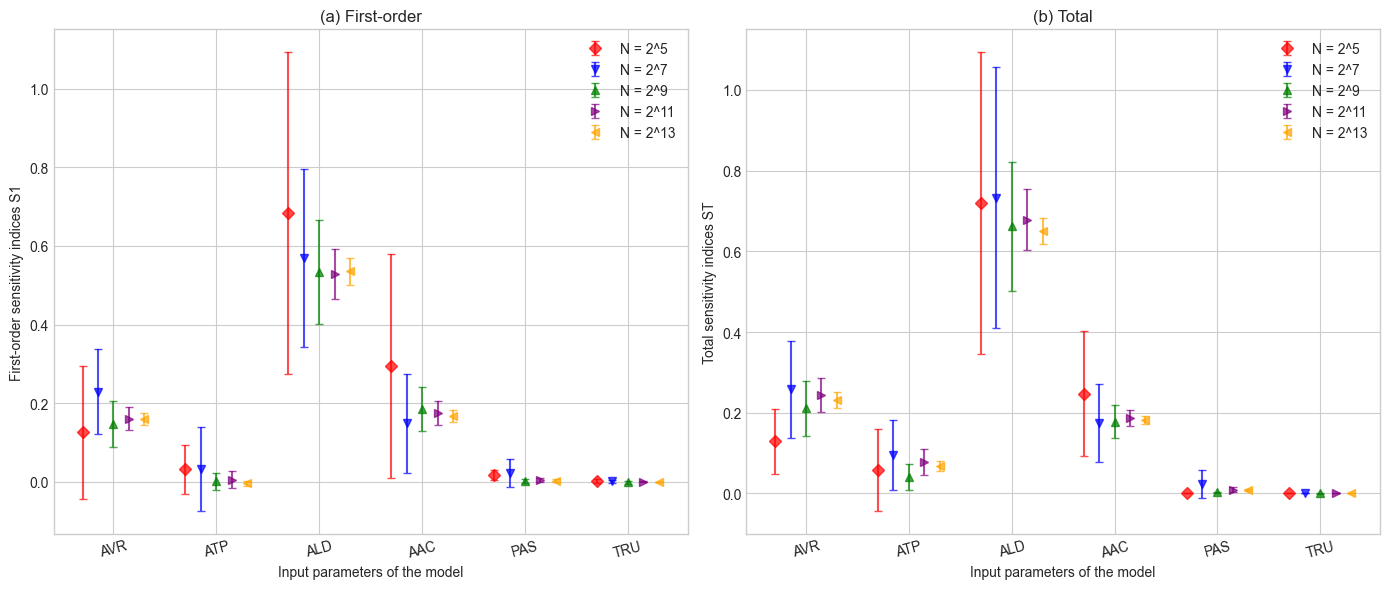


PART 2: DIRECTIONAL IMPACT ANALYSIS ON DOMAIN [1, 7]
PERCENTAGE OF DIRECTIONAL IMPACTS ACROSS THE DOMAIN [1, 7]:
----------------------------------------------------------------------------------------------------
Variable Acc. Increase (%) Dec. Increase (%) Acc. Decrease (%) Dec. Decrease (%)        Dominant Trend
     AVR              0.0%            100.0%              0.0%              0.0% Decelerating Increase
     ATP              0.0%            100.0%              0.0%              0.0% Decelerating Increase
     ALD              0.0%            100.0%              0.0%              0.0% Decelerating Increase
     AAC              0.0%            100.0%              0.0%              0.0% Decelerating Increase
     PAS              0.0%              0.0%            100.0%              0.0% Accelerating Decrease
     TRU              0.0%            100.0%              0.0%              0.0% Decelerating Increase
----------------------------------------------------------------

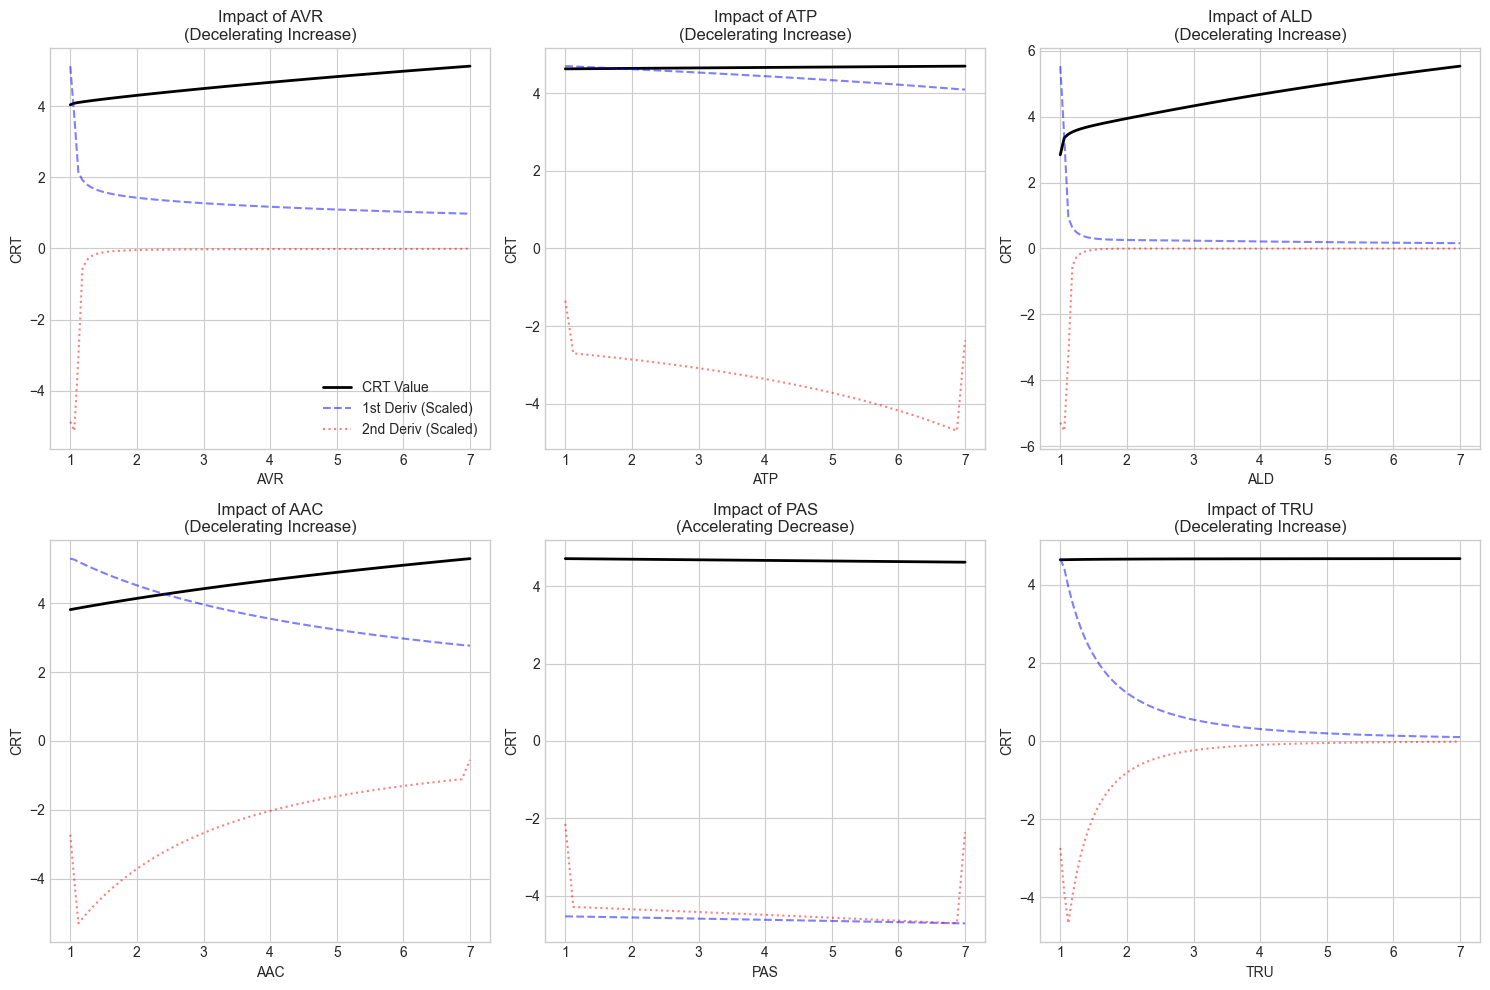

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from SALib.sample import saltelli
from SALib.analyze import sobol
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# MATHEMATICAL FUNCTION DEFINITION
# ==========================================
def evaluate_CRT(X):
    """
    Function to calculate CRT based on input matrix X with 6 columns:
    [AVR, ATP, ALD, AAC, PAS, TRU]
    """
    AVR = X[:, 0]
    ATP = X[:, 1]
    ALD = X[:, 2]
    AAC = X[:, 3]
    PAS = X[:, 4]
    TRU = X[:, 5]
    
    # Use np.cbrt for safe cubic root calculation (handles negative numbers)
    part1 = np.cbrt(AVR - ATP/ALD) / ALD + ALD
    part2 = AAC / 0.655 + AVR
    inner = part1 * part2 * 2.323 - PAS + ATP - 0.559 * (AVR / TRU)
    
    CRT = np.cbrt(inner)
    return CRT

features = ['AVR', 'ATP', 'ALD', 'AAC', 'PAS', 'TRU']

print("\n" + "="*60)
print("PART 1: SOBOL SENSITIVITY ANALYSIS & CONVERGENCE")
print("="*60)

# 1. Problem declaration (Domain [1, 7] for all variables)
problem = {
    'num_vars': len(features),
    'names': features,
    'bounds': [[1.0, 7.0] for _ in features]
}

# 2. Multi-sample size survey
N_values = [2**5, 2**7, 2**9, 2**11, 2**13]

results_S1 = {feature: [] for feature in features}
results_ST = {feature: [] for feature in features}
errors_S1 = {feature: [] for feature in features}
errors_ST = {feature: [] for feature in features}

print(f"Running survey for sample sizes N = {N_values}...\n")

for n in N_values:
    # Sampling
    param_values = saltelli.sample(problem, n)
    
    # Predicting using the CRT function
    Y_pred = evaluate_CRT(param_values)
    
    # Analysis
    Si = sobol.analyze(problem, Y_pred, print_to_console=False)
    
    for i, feature in enumerate(features):
        results_S1[feature].append(Si['S1'][i])
        results_ST[feature].append(Si['ST'][i])
        errors_S1[feature].append(Si['S1_conf'][i])
        errors_ST[feature].append(Si['ST_conf'][i])

# 3. Export summary table (At N=2^13)
final_samples = saltelli.sample(problem, 2**13)
final_Si = sobol.analyze(problem, evaluate_CRT(final_samples), print_to_console=False)

table_4 = pd.DataFrame({
    'Input Variables': features,
    'First-order S1': final_Si['S1'],
    'Total S_T': final_Si['ST']
})
print("SUMMARY TABLE OF SOBOL INDICES (At N = 2^13):")
print("-" * 60)
print(table_4.to_string(index=False))
print("-" * 60)

# 4. Plot Sobol confidence intervals
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors = ['red', 'blue', 'green', 'purple', 'orange']
markers = ['D', 'v', '^', '>', '<']
x_pos = np.arange(len(features))

for i, n in enumerate(N_values):
    s1_vals = [results_S1[feat][i] for feat in features]
    s1_errs = [errors_S1[feat][i] for feat in features]
    offset = (i - 2) * 0.15
    ax1.errorbar(x_pos + offset, s1_vals, yerr=s1_errs, fmt=markers[i], color=colors[i],
                 label=f'N = 2^{int(np.log2(n))}', capsize=3, alpha=0.7)

ax1.set_xticks(x_pos)
ax1.set_xticklabels(features, rotation=15)
ax1.set_ylabel('First-order sensitivity indices S1')
ax1.set_xlabel('Input parameters of the model')
ax1.set_title('(a) First-order')
ax1.legend()

for i, n in enumerate(N_values):
    st_vals = [results_ST[feat][i] for feat in features]
    st_errs = [errors_ST[feat][i] for feat in features]
    offset = (i - 2) * 0.15
    ax2.errorbar(x_pos + offset, st_vals, yerr=st_errs, fmt=markers[i], color=colors[i],
                 label=f'N = 2^{int(np.log2(n))}', capsize=3, alpha=0.7)

ax2.set_xticks(x_pos)
ax2.set_xticklabels(features, rotation=15)
ax2.set_ylabel('Total sensitivity indices ST')
ax2.set_xlabel('Input parameters of the model')
ax2.set_title('(b) Total')
ax2.legend()

plt.tight_layout()
plt.show()

# ==========================================
# PART 2: DIRECTIONAL IMPACT ANALYSIS ON DOMAIN [1, 7] (PERCENTAGE TABLE)
# ==========================================
print("\n" + "="*60)
print("PART 2: DIRECTIONAL IMPACT ANALYSIS ON DOMAIN [1, 7]")
print("="*60)

# Fix other variables at the mean value = 4.0
base_values = np.array([4.0] * 6)
num_points = 100
x_eval = np.linspace(1, 7, num_points)
dx = x_eval[1] - x_eval[0]

# Prepare list to store data for the table
impact_data = []

fig2, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    # Create input matrix with the current variable changing, others fixed
    X_test = np.tile(base_values, (num_points, 1))
    X_test[:, i] = x_eval
    
    # Calculate Y, 1st and 2nd derivatives
    Y_eval = evaluate_CRT(X_test)
    dy_dx = np.gradient(Y_eval, dx)
    d2y_dx2 = np.gradient(dy_dx, dx)
    
    # Calculate percentages for each trend
    # Avoid exact zero comparison issues by using a very small threshold if needed, 
    # but strictly following the mathematical signs:
    acc_inc = np.sum((dy_dx > 0) & (d2y_dx2 > 0)) / num_points * 100
    dec_inc = np.sum((dy_dx > 0) & (d2y_dx2 <= 0)) / num_points * 100
    acc_dec = np.sum((dy_dx < 0) & (d2y_dx2 < 0)) / num_points * 100
    dec_dec = np.sum((dy_dx < 0) & (d2y_dx2 >= 0)) / num_points * 100
    
    # In case there are flat regions (dy == 0)
    flat_region = np.sum(dy_dx == 0) / num_points * 100
    
    # Determine Dominant Trend
    trends = {
        "Accelerating Increase": acc_inc,
        "Decelerating Increase": dec_inc,
        "Accelerating Decrease": acc_dec,
        "Decelerating Decrease": dec_dec,
        "Flat/No Change": flat_region
    }
    dominant_trend = max(trends, key=trends.get)
    
    # Append to table data
    impact_data.append({
        'Variable': feature,
        'Acc. Increase (%)': f"{acc_inc:.1f}%",
        'Dec. Increase (%)': f"{dec_inc:.1f}%",
        'Acc. Decrease (%)': f"{acc_dec:.1f}%",
        'Dec. Decrease (%)': f"{dec_dec:.1f}%",
        'Dominant Trend': dominant_trend
    })
    
    # Plotting
    ax = axes[i]
    ax.plot(x_eval, Y_eval, 'k-', linewidth=2, label='CRT Value')
    ax.set_title(f'Impact of {feature}\n({dominant_trend})')
    ax.set_xlabel(feature)
    ax.set_ylabel('CRT')
    
    # Add derivative lines (Scaled for visibility on the same axis)
    ax.plot(x_eval, dy_dx * np.max(np.abs(Y_eval))/np.max(np.abs(dy_dx)), 'b--', alpha=0.5, label="1st Deriv (Scaled)")
    ax.plot(x_eval, d2y_dx2 * np.max(np.abs(Y_eval))/np.max(np.abs(d2y_dx2)), 'r:', alpha=0.5, label="2nd Deriv (Scaled)")
    
    if i == 0:
        ax.legend()

# ------------------------------------------
# Xuất bảng kết quả
# ------------------------------------------
impact_df = pd.DataFrame(impact_data)
print("PERCENTAGE OF DIRECTIONAL IMPACTS ACROSS THE DOMAIN [1, 7]:")
print("-" * 100)
print(impact_df.to_string(index=False))
print("-" * 100)

plt.tight_layout()
plt.show()